In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/dataco-smart-supply-chain-for-big-data-analysis/tokenized_access_logs.csv
/kaggle/input/dataco-smart-supply-chain-for-big-data-analysis/DataCoSupplyChainDataset.csv
/kaggle/input/dataco-smart-supply-chain-for-big-data-analysis/DescriptionDataCoSupplyChain.csv


In [2]:
#setting up
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.plotting.register_matplotlib_converters()
%matplotlib inline
import duckdb

print('Setup completed')

Setup completed


In [3]:
#loading the datasets
file="/kaggle/input/dataco-smart-supply-chain-for-big-data-analysis/DataCoSupplyChainDataset.csv"

df=pd.read_csv(file,encoding='Windows-1252')
df.head

<bound method NDFrame.head of             Type  Days for shipping (real)  Days for shipment (scheduled)  \
0          DEBIT                         3                              4   
1       TRANSFER                         5                              4   
2           CASH                         4                              4   
3          DEBIT                         3                              4   
4        PAYMENT                         2                              4   
...          ...                       ...                            ...   
180514      CASH                         4                              4   
180515     DEBIT                         3                              2   
180516  TRANSFER                         5                              4   
180517   PAYMENT                         3                              4   
180518   PAYMENT                         4                              4   

        Benefit per order  Sales per customer

## Cleaning/Scrubbing data

In [4]:
#handling missing values
print(f"Missing values:\n{df.isnull().sum()}")

#dropping columns with all or high null rows
df=df.drop(['Order Zipcode','Product Description'], axis=1)

#dropping columns with PII or no relevant inf0
df=df.drop(['Customer Email','Customer Fname','Customer Lname','Customer Password',
            'Product Status','Order Item Id','Product Image'], axis=1)
#dropping rows with missing data
df=df.dropna()
print(f"\nAdjusted Data:\n{df.isnull().sum()}")
print(f"Data size: {df.shape}")

Missing values:
Type                                  0
Days for shipping (real)              0
Days for shipment (scheduled)         0
Benefit per order                     0
Sales per customer                    0
Delivery Status                       0
Late_delivery_risk                    0
Category Id                           0
Category Name                         0
Customer City                         0
Customer Country                      0
Customer Email                        0
Customer Fname                        0
Customer Id                           0
Customer Lname                        8
Customer Password                     0
Customer Segment                      0
Customer State                        0
Customer Street                       0
Customer Zipcode                      3
Department Id                         0
Department Name                       0
Latitude                              0
Longitude                             0
Market                  

In [5]:
#handling duplicates
print(f"\nDuplicate rows: {df.duplicated().sum()}")

# Compare columns
are_cols_equal = df['Benefit per order'].equals(df['Order Profit Per Order'])
print(f"Are Benefit per order and Order Profit Per Order identical? {are_cols_equal}")

are_cols_equal2 = df['Customer Id'].equals(df['Order Customer Id'])
print(f"Are Customer Id and Order Customer Id identical? {are_cols_equal2}")

are_cols_equal3 = df['Order Item Cardprod Id'].equals(df['Product Card Id'])
print(f"Are Order Item Cardprod Id and Product Card Id identical? {are_cols_equal3}")

are_cols_equal3 = df['Product Category Id'].equals(df['Category Id'])
print(f"Are Category Id and Product Category Id lidentica? {are_cols_equal3}")

are_cols_equal3 = df['Product Price'].equals(df['Order Item Product Price'])
print(f"Are Order Item Product Price and Product Price lidentica? {are_cols_equal3}")


#dropping duplicated columns
df=df.drop(['Benefit per order','Order Customer Id','Product Card Id','Product Category Id','Product Price'], axis=1)

print(f"Data size: {df.shape}")


Duplicate rows: 0
Are Benefit per order and Order Profit Per Order identical? True
Are Customer Id and Order Customer Id identical? True
Are Order Item Cardprod Id and Product Card Id identical? True
Are Category Id and Product Category Id lidentica? True
Are Order Item Product Price and Product Price lidentica? True
Data size: (180516, 39)


In [6]:
#handling formatting
print(df.dtypes)
# Convert only the true date columns to datetime
date_columns = [
    "order date (DateOrders)",
    "shipping date (DateOrders)"
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col], format='mixed', errors='coerce')
#convert categorical columns to str/objects
cat_cols= [
"Late_delivery_risk","Category Id","Customer Id","Customer Zipcode","Department Id",
"Order Id","Order Item Cardprod Id"]

df[cat_cols]=df[cat_cols].astype(str)

print(f"\nCorrected format: {df.dtypes}")

Type                              object
Days for shipping (real)           int64
Days for shipment (scheduled)      int64
Sales per customer               float64
Delivery Status                   object
Late_delivery_risk                 int64
Category Id                        int64
Category Name                     object
Customer City                     object
Customer Country                  object
Customer Id                        int64
Customer Segment                  object
Customer State                    object
Customer Street                   object
Customer Zipcode                 float64
Department Id                      int64
Department Name                   object
Latitude                         float64
Longitude                        float64
Market                            object
Order City                        object
Order Country                     object
order date (DateOrders)           object
Order Id                           int64
Order Item Cardp

## Initial EDA

In [7]:
# descriptive statistics
print(df.describe())



       Days for shipping (real)  Days for shipment (scheduled)  \
count             180516.000000                  180516.000000   
mean                   3.497657                       2.931845   
min                    0.000000                       0.000000   
25%                    2.000000                       2.000000   
50%                    3.000000                       4.000000   
75%                    5.000000                       4.000000   
max                    6.000000                       4.000000   
std                    1.623731                       1.374449   

       Sales per customer       Latitude      Longitude  \
count       180516.000000  180516.000000  180516.000000   
mean           183.107723      29.719830     -84.915074   
min              7.490000     -33.937553    -158.025986   
25%            104.379997      18.265432     -98.446312   
50%            163.990005      33.144863     -76.840759   
75%            247.399994      39.279617     -66.37

In [8]:
# getting all the columns
pd.set_option('display.max_columns', None)

#describing categorical columns
print(df.describe(include=object))

          Type Delivery Status Late_delivery_risk Category Id Category Name  \
count   180516          180516             180516      180516        180516   
unique       4               4                  2          51            50   
top      DEBIT   Late delivery                  1          17        Cleats   
freq     69293           98976              98976       24551         24551   

       Customer City Customer Country Customer Id Customer Segment  \
count         180516           180516      180516           180516   
unique           562                2       20649                3   
top           Caguas          EE. UU.        5654         Consumer   
freq           66770           111143          47            93502   

       Customer State          Customer Street Customer Zipcode Department Id  \
count          180516                   180516           180516        180516   
unique             44                     7456              995            11   
top       

In [9]:
#insights with sql
print(f'{duckdb.sql('SELECT "Delivery Status",avg("Order Item Discount Rate"), avg("Sales per customer"), avg("Days for shipping (real)"),avg("Days for shipment (scheduled)"), avg("Order Profit Per Order") FROM df GROUP BY "Delivery Status"').df()}')

print(f'\n{duckdb.sql('SELECT "Shipping Mode",avg("Order Item Discount Rate"), avg("Sales per customer"), avg("Days for shipping (real)"),avg("Days for shipment (scheduled)"), avg("Order Profit Per Order") FROM df GROUP BY "Shipping Mode"').df()}')

print(f'\n{duckdb.sql('SELECT "Order Status",avg("Order Item Discount Rate"), avg("Sales per customer"), avg("Days for shipping (real)"),avg("Days for shipment (scheduled)"), avg("Order Profit Per Order") FROM df GROUP BY "Order Status"').df()}')

print(f'\n{duckdb.sql('SELECT "Category Id", "Category Name", count("Category Name") as count, avg("Order Profit Per Order") FROM df GROUP BY "Category Name", "Category Id"').df()}')

print(f'\n{duckdb.sql('SELECT "Order Status", "Delivery Status", avg("Order Profit Per Order") FROM df GROUP BY "Order Status", "Delivery Status" ORDER BY "Order Status", "Delivery Status"').df()}')

     Delivery Status  avg("Order Item Discount Rate")  \
0  Shipping canceled                         0.102632   
1   Advance shipping                         0.101690   
2   Shipping on time                         0.101329   
3      Late delivery                         0.101693   

   avg("Sales per customer")  avg("Days for shipping (real)")  \
0                 181.807751                         3.476657   
1                 184.082005                         2.498149   
2                 183.432693                         2.975151   
3                 182.694448                         4.089274   

   avg("Days for shipment (scheduled)")  avg("Order Profit Per Order")  
0                              2.903921                      20.696717  
1                              4.000000                      22.485701  
2                              2.975151                      22.708355  
3                              2.471084                      21.621255  

    Shipping Mode  avg

## Feature Engineering

In [10]:
# creating year, quater and month columns base on  order date (DateOrders)
df['year']=df["order date (DateOrders)"].dt.year
df['quarter']=df["order date (DateOrders)"].dt.quarter
df['month']=df["order date (DateOrders)"].dt.month

##creating shipping_variance
df['shipping_variance']= df["Days for shipping (real)"]-df["Days for shipment (scheduled)"]

#creating order_shipping_lag
df['order_shipping_lag']= (df["shipping date (DateOrders)"]-df["order date (DateOrders)"]).dt.days

#creating profited
df["profited"]= df["Order Profit Per Order"]>0

df.head

<bound method NDFrame.head of             Type  Days for shipping (real)  Days for shipment (scheduled)  \
0          DEBIT                         3                              4   
1       TRANSFER                         5                              4   
2           CASH                         4                              4   
3          DEBIT                         3                              4   
4        PAYMENT                         2                              4   
...          ...                       ...                            ...   
180514      CASH                         4                              4   
180515     DEBIT                         3                              2   
180516  TRANSFER                         5                              4   
180517   PAYMENT                         3                              4   
180518   PAYMENT                         4                              4   

        Sales per customer   Delivery Status 

In [11]:
#get file out
df.to_csv('sales_file.csv', index=False)

## EDA
Visualize data for insights

/tmp/ipykernel_17/3815543060.py:15: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot( data=df, x="month",hue="year",ax=axes[1,1])
/tmp/ipykernel_17/3815543060.py:18: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot( data=df,x="quarter",hue= "year", ax=axes[2,0])


<Axes: title={'center': 'Distribution of shipping variance'}, xlabel='shipping_variance', ylabel='Density'>

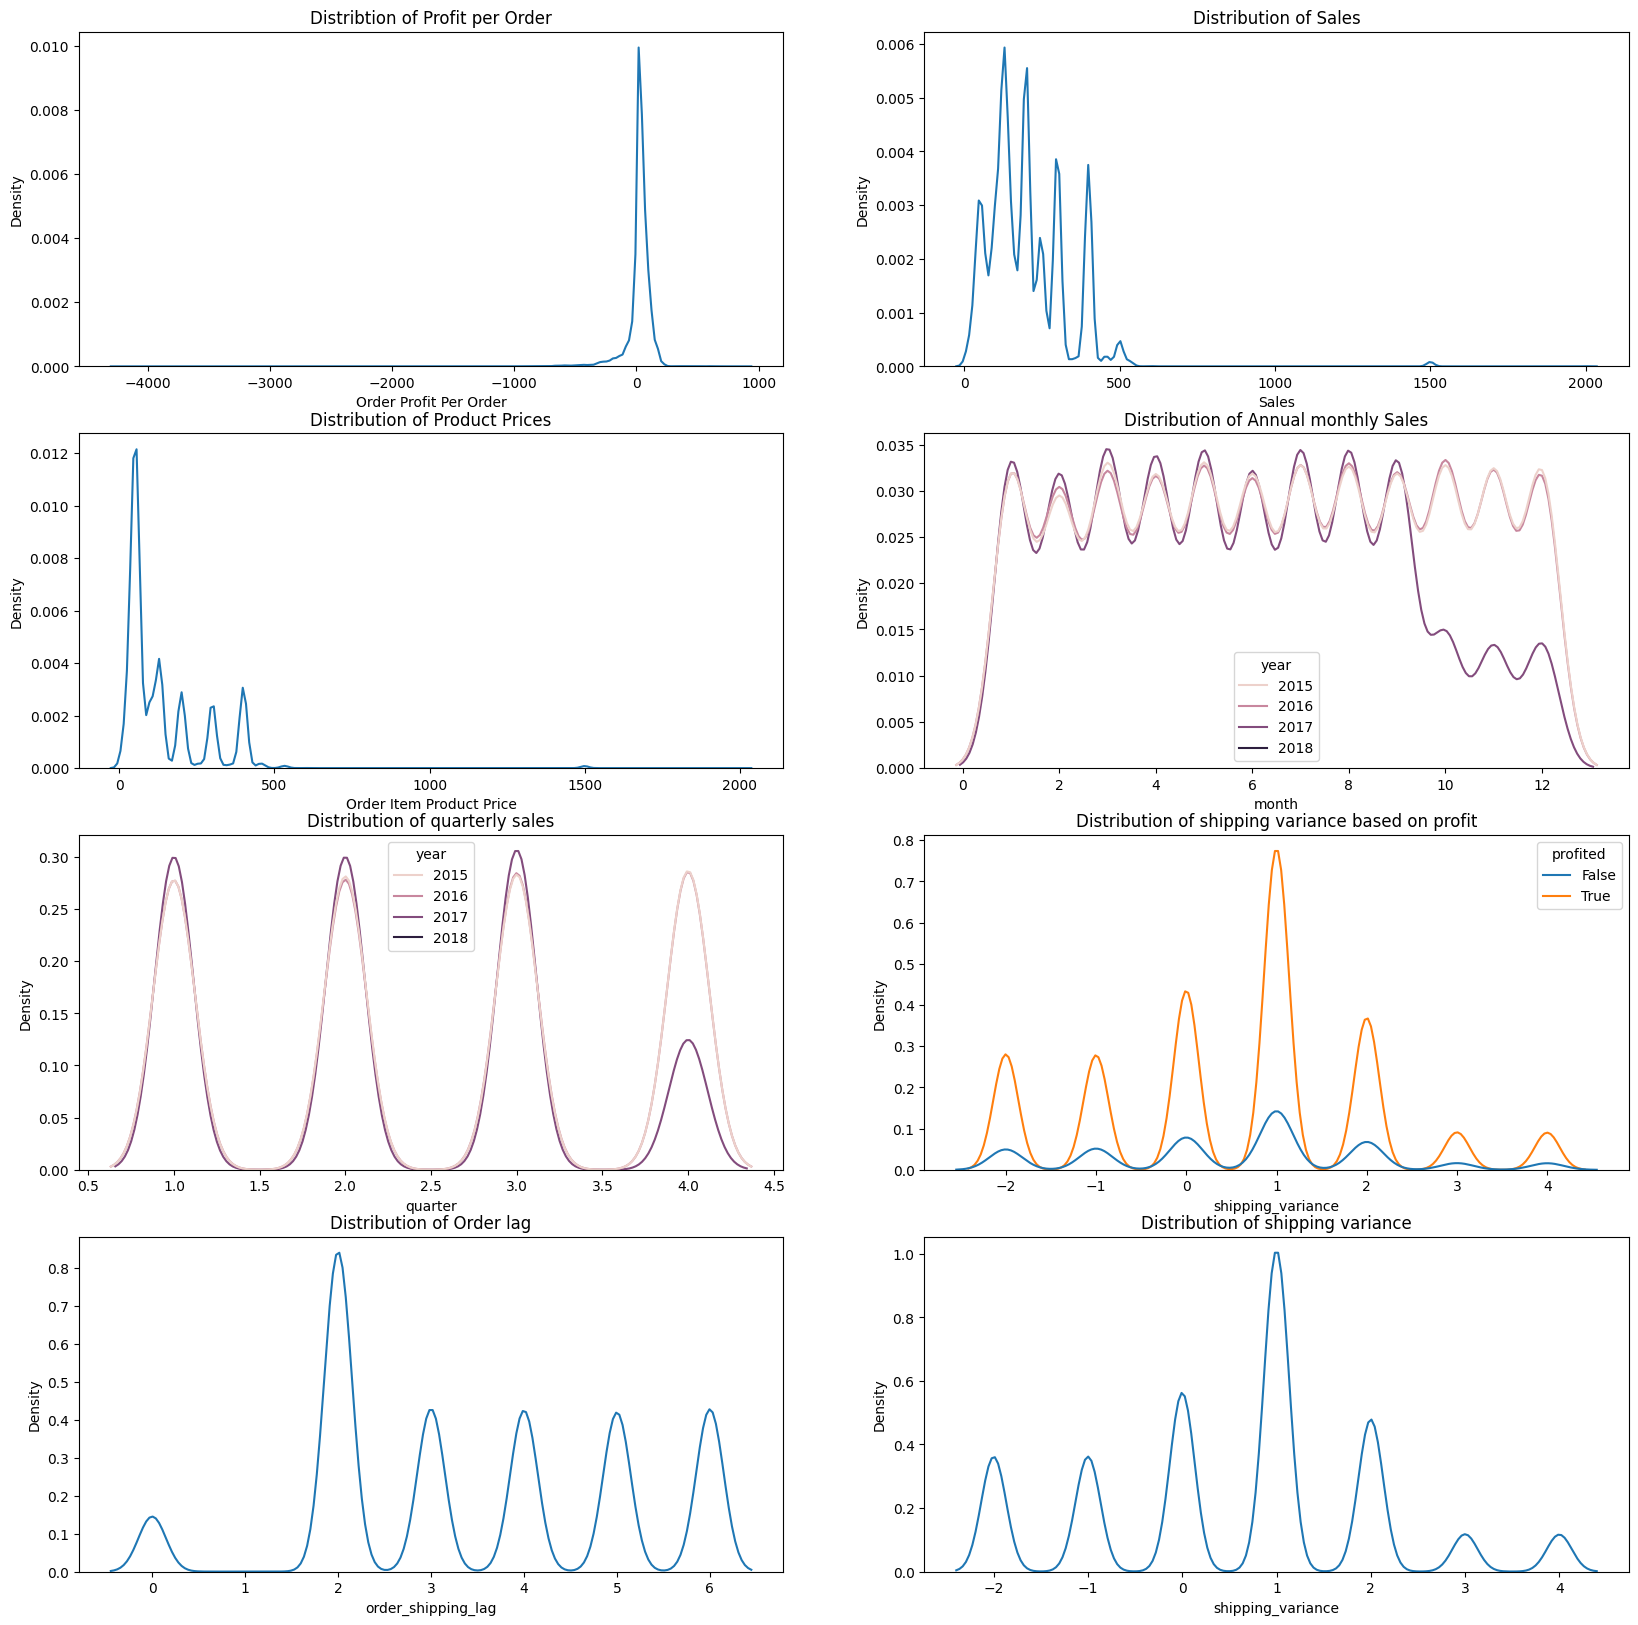

In [12]:
# distribution of variables
fig,axes=plt.subplots(nrows=4,ncols=2, figsize=(20,20))
axes[0,0].set_title("Distribtion of Profit per Order")
#sns.histplot( df["Order Profit Per Order"], ax=axes[0,0])
sns.kdeplot( df["Order Profit Per Order"], ax=axes[0,0])

axes[0,1].set_title("Distribution of Sales")
#sns.histplot( df["Sales"],ax=axes[0,1])
sns.kdeplot( df["Sales"],ax=axes[0,1])

axes[1,0].set_title("Distribution of Product Prices")
sns.kdeplot( df["Order Item Product Price"],ax=axes[1,0])

axes[1,1].set_title("Distribution of Annual monthly Sales")
sns.kdeplot( data=df, x="month",hue="year",ax=axes[1,1])

axes[2,0].set_title("Distribution of quarterly sales")
sns.kdeplot( data=df,x="quarter",hue= "year", ax=axes[2,0])

axes[2,1].set_title("Distribution of shipping variance based on profit")
sns.kdeplot( data=df, x="shipping_variance",hue="profited",ax=axes[2,1])

axes[3,0].set_title("Distribution of Order lag")
sns.kdeplot( df["order_shipping_lag"],ax=axes[3,0])

axes[3,1].set_title("Distribution of shipping variance")
sns.kdeplot( df["shipping_variance"],ax=axes[3,1])

/tmp/ipykernel_17/3305401268.py:38: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(data=df, ax=axes[2], x="Category Id", y="Order Profit Per Order",ci=95)


<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

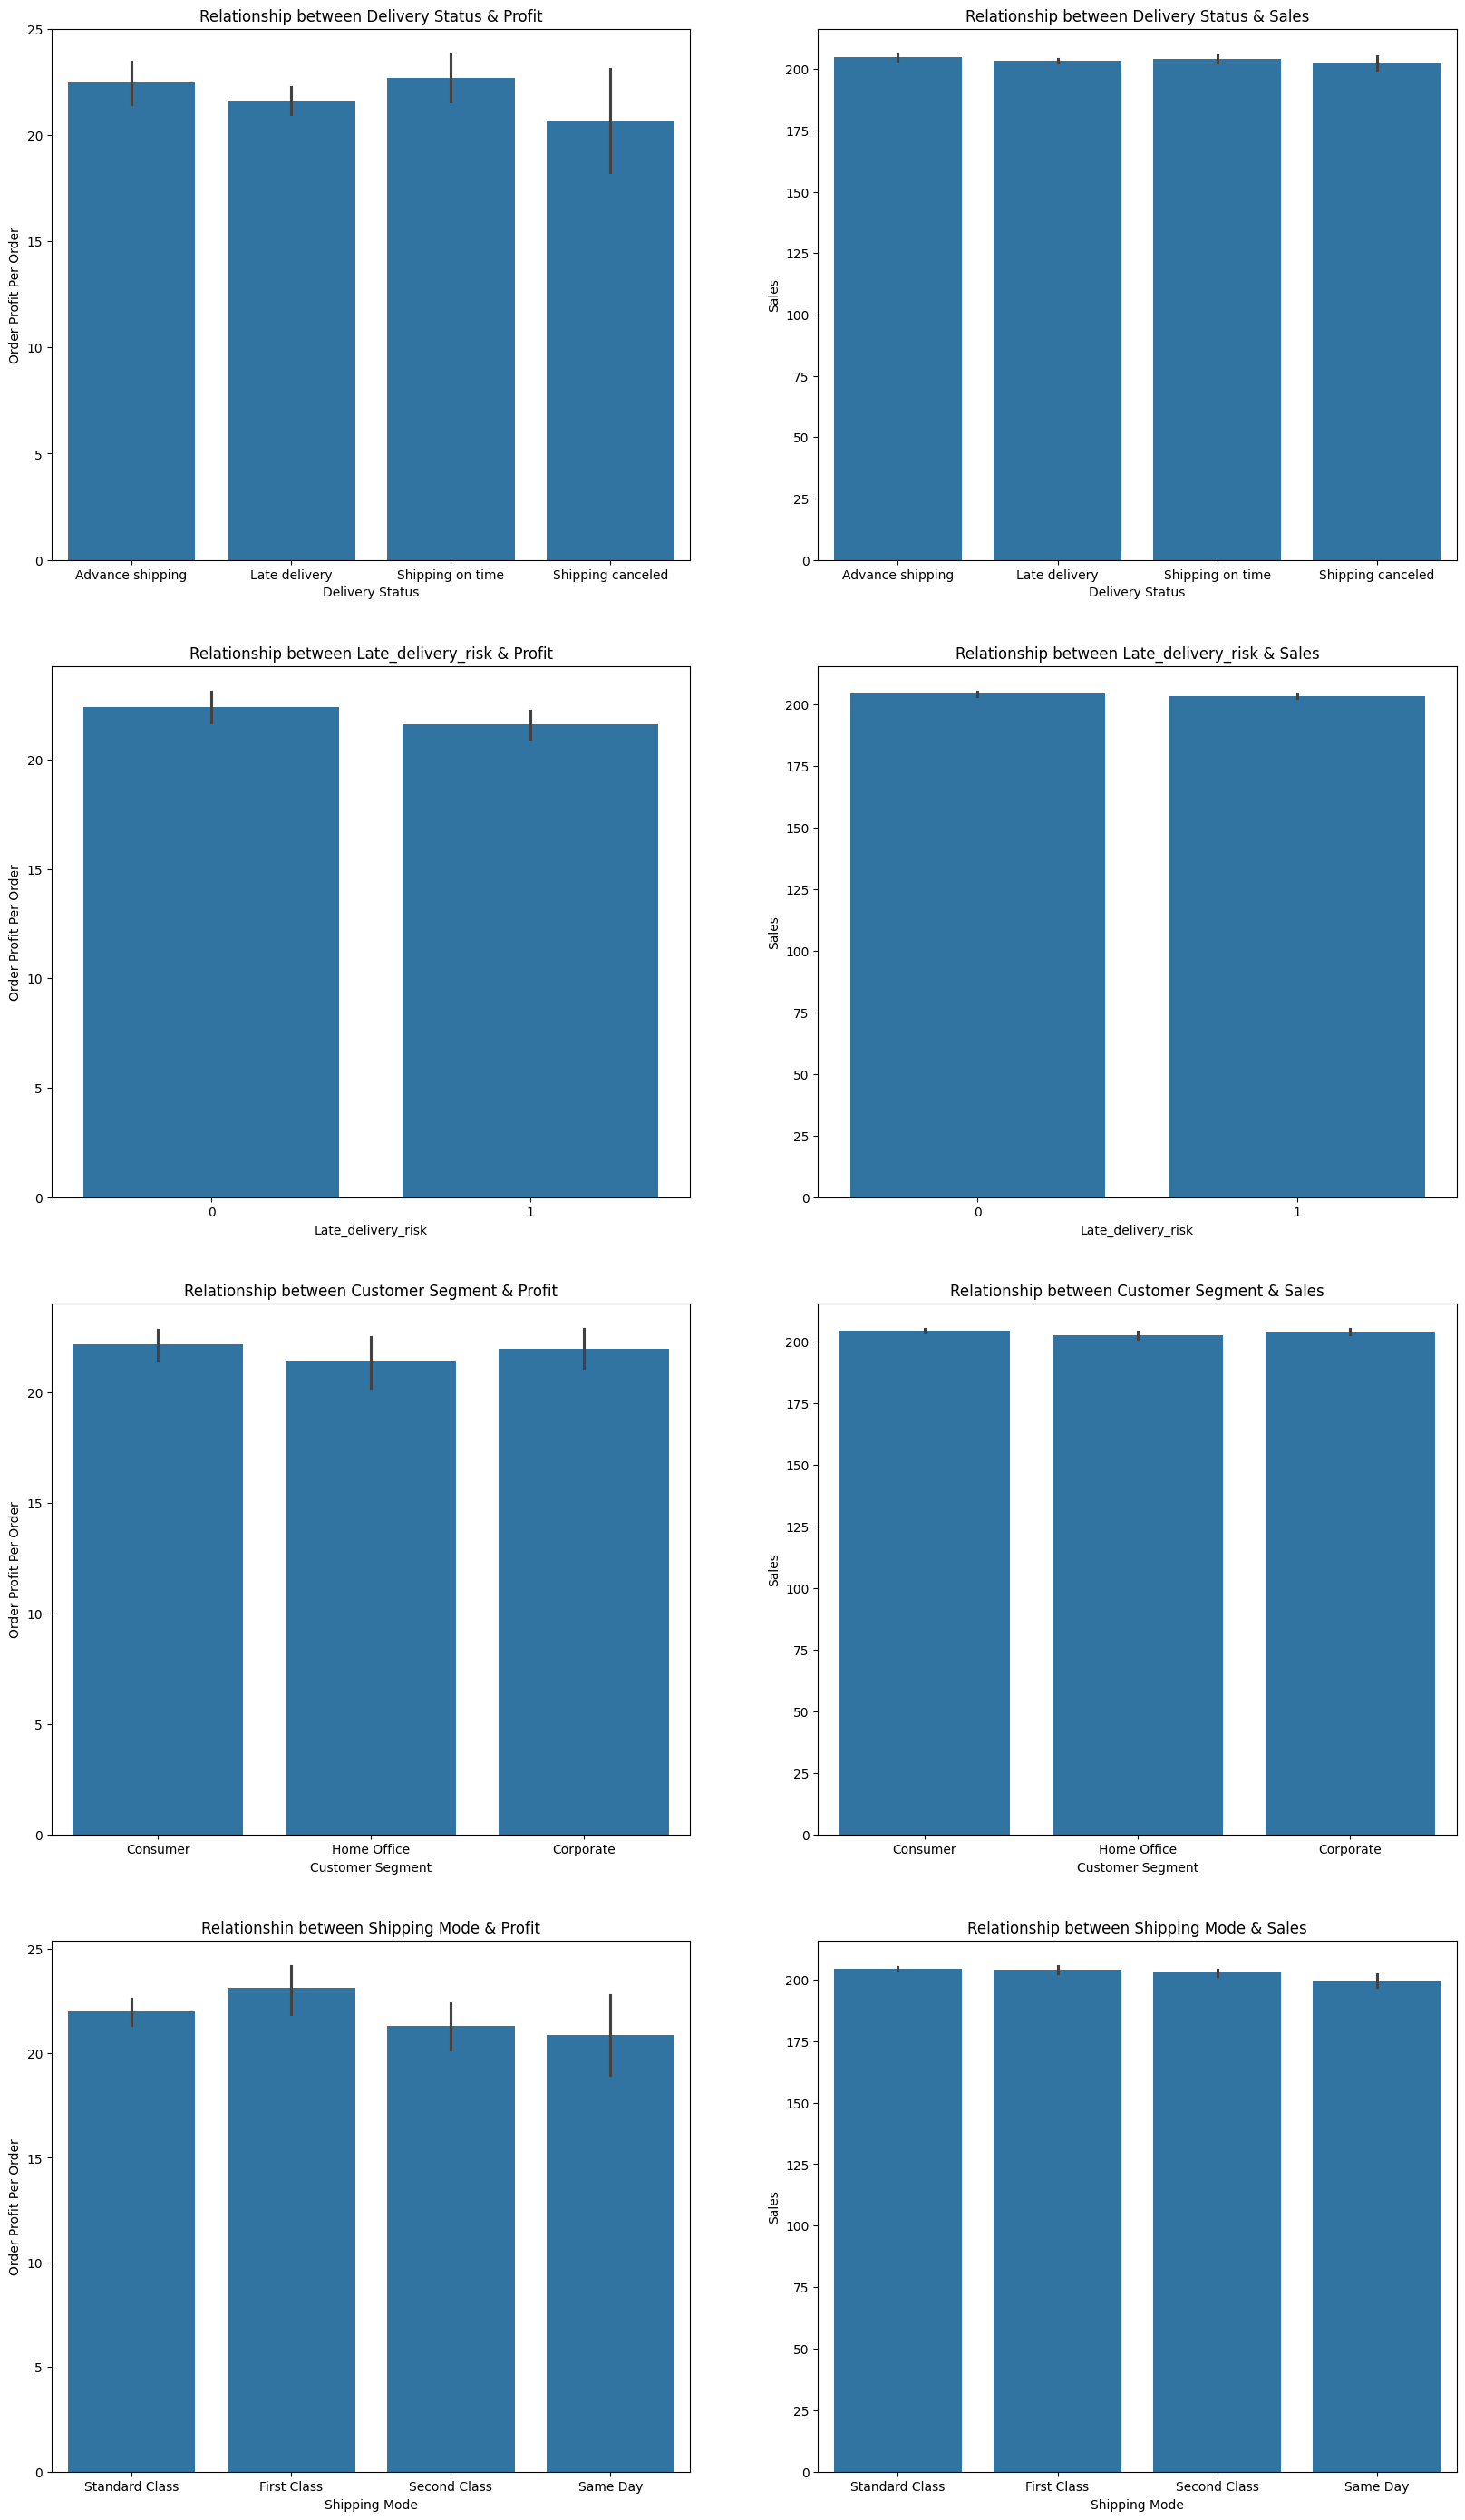

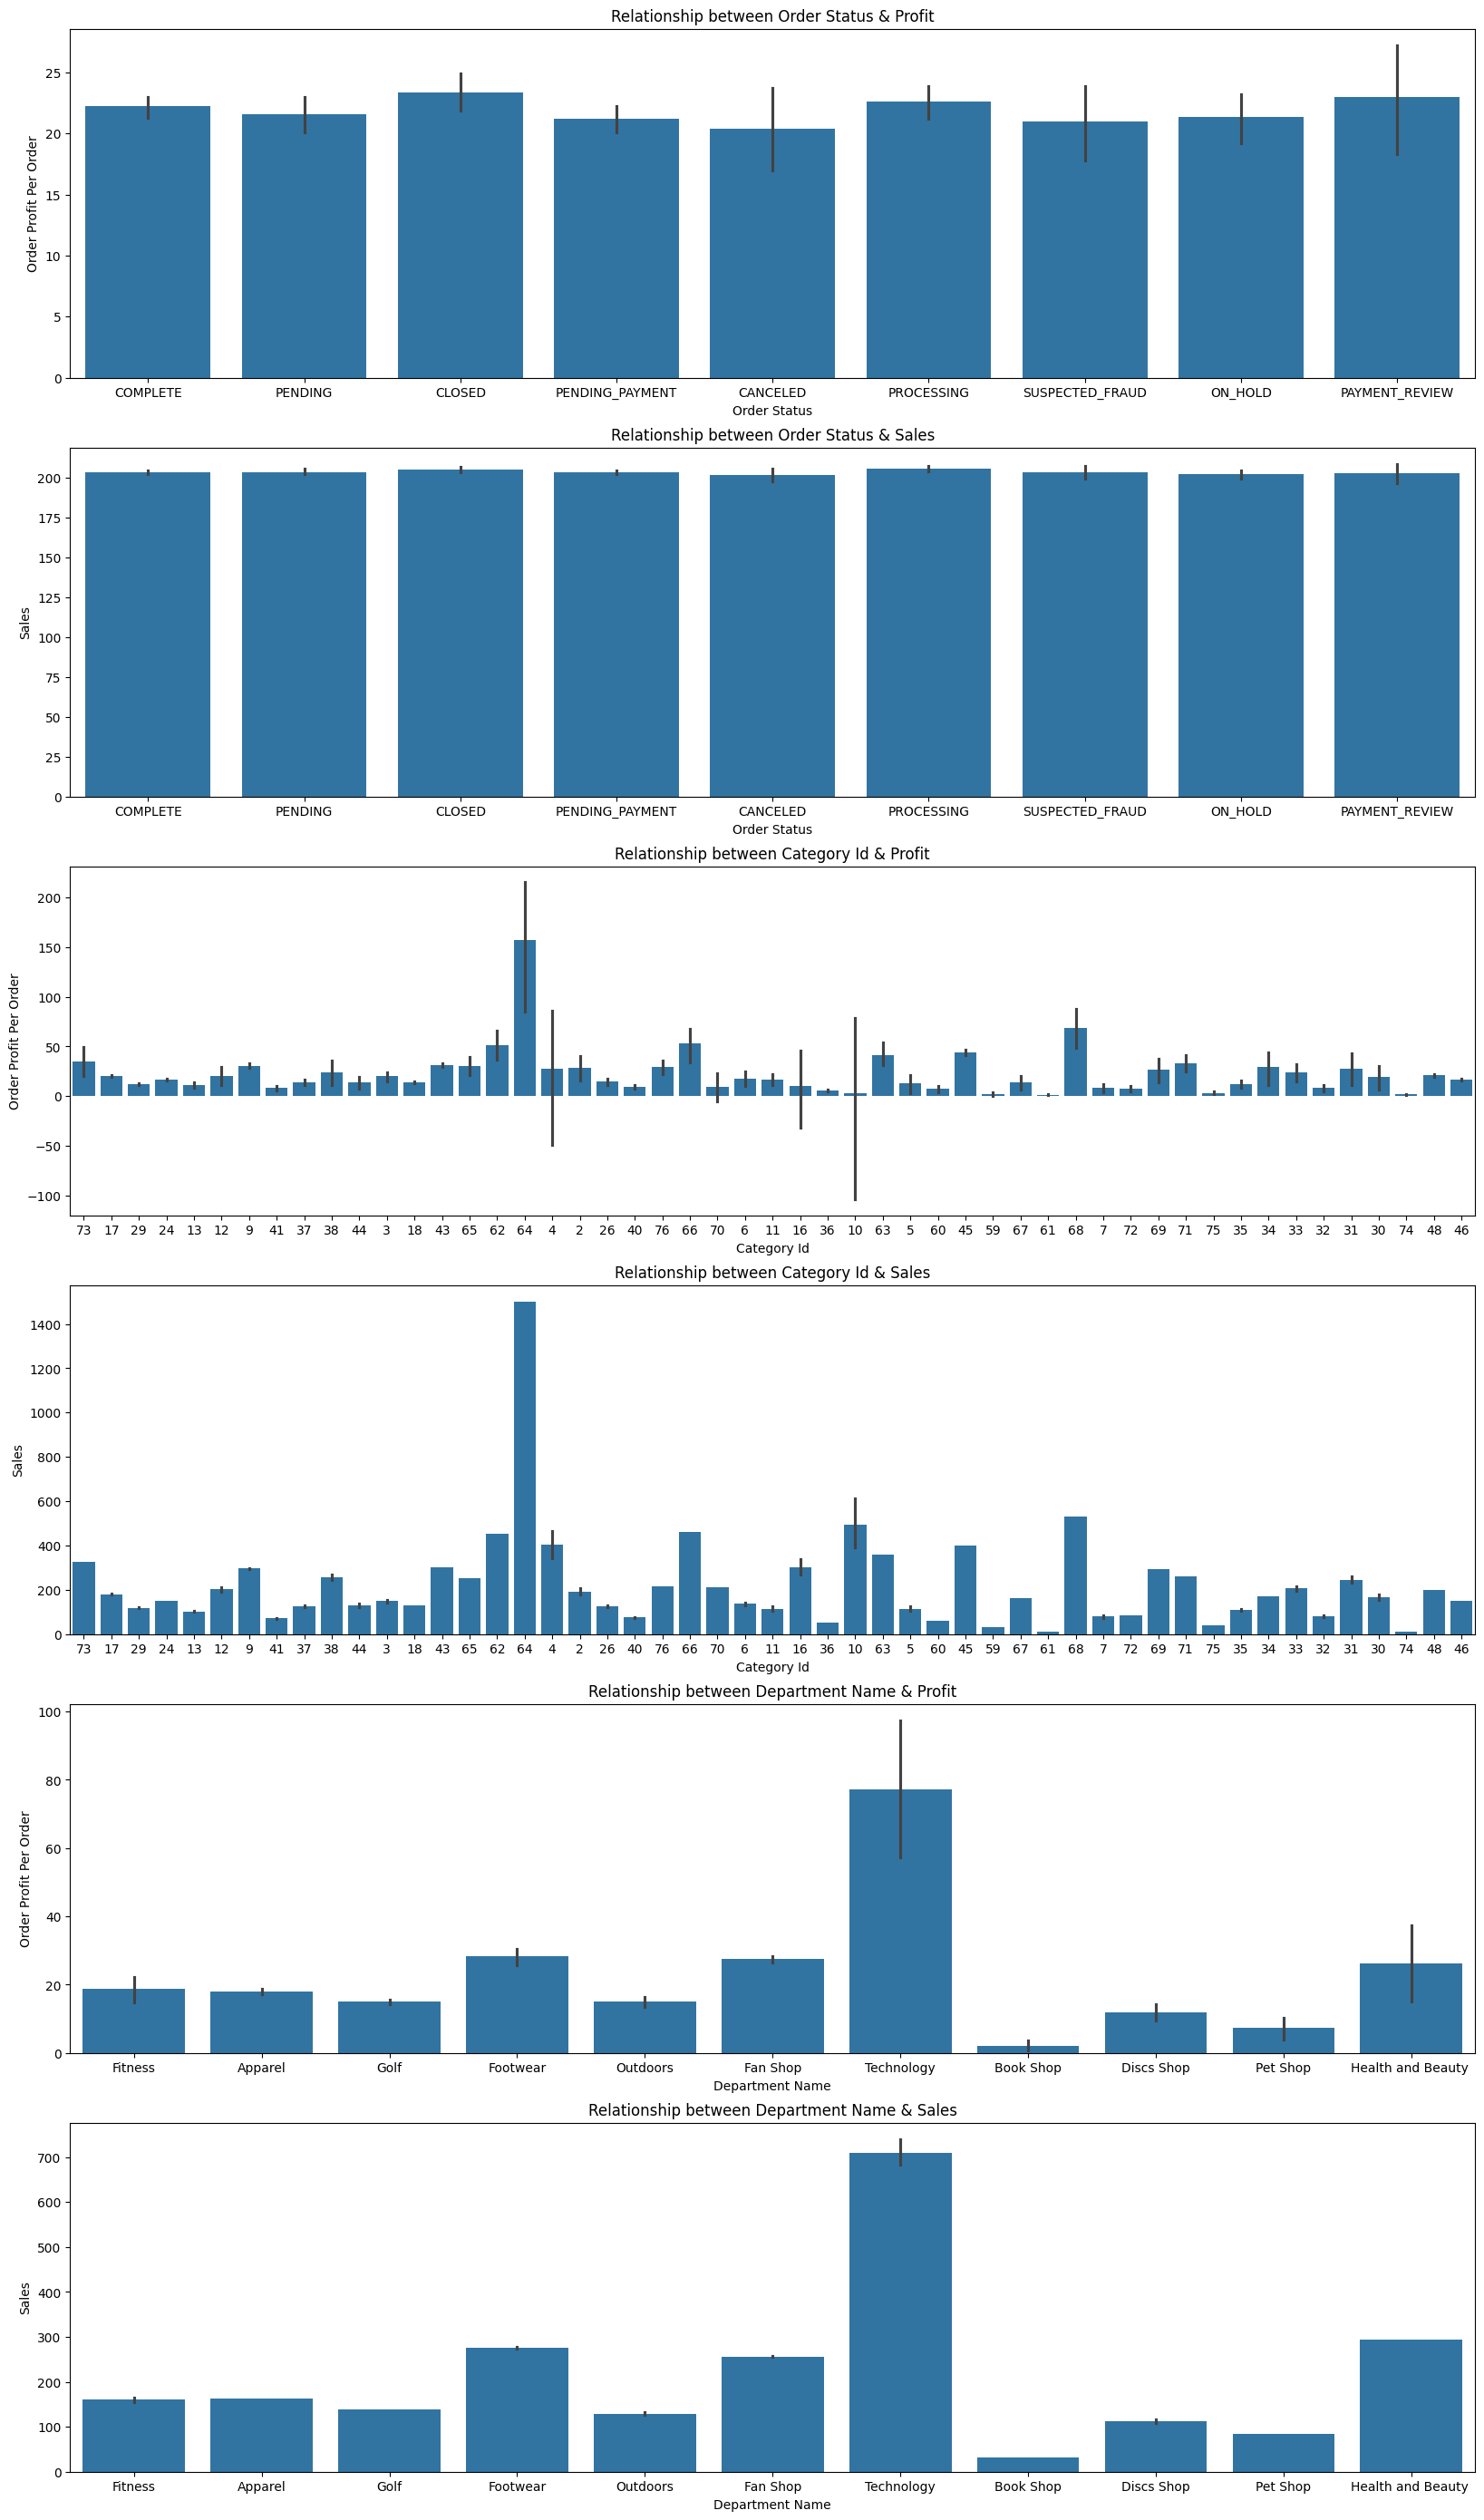

In [13]:
# barplots to show relationship between categorical variables and profit/sales
fig,axes=plt.subplots(nrows=4,ncols=2, figsize=(20,35))

axes[0,0].set_title("Relationship between Delivery Status & Profit")
sns.barplot(data=df, ax=axes[0,0], x="Delivery Status", y="Order Profit Per Order")

axes[0,1].set_title("Relationship between Delivery Status & Sales")
sns.barplot(data=df, ax=axes[0,1], x="Delivery Status", y="Sales")

axes[1,0].set_title("Relationship between Late_delivery_risk & Profit")
sns.barplot(data=df, ax=axes[1,0], x="Late_delivery_risk", y="Order Profit Per Order")

axes[1,1].set_title("Relationship between Late_delivery_risk & Sales")
sns.barplot(data=df, ax=axes[1,1], x="Late_delivery_risk", y="Sales")

axes[2,0].set_title("Relationship between Customer Segment & Profit")
sns.barplot(data=df, ax=axes[2,0], x="Customer Segment", y="Order Profit Per Order")

axes[2,1].set_title("Relationship between Customer Segment & Sales")
sns.barplot(data=df, ax=axes[2,1], x="Customer Segment", y="Sales")

axes[3,0].set_title("Relationshin between Shipping Mode & Profit")
sns.barplot(data=df, ax=axes[3,0], x="Shipping Mode", y="Order Profit Per Order")

axes[3,1].set_title("Relationship between Shipping Mode & Sales")
sns.barplot(data=df, ax=axes[3,1], x="Shipping Mode", y="Sales")

plt.tight_layout

fig,axes=plt.subplots(nrows=6,ncols=1, figsize=(20,35))
axes[0].set_title("Relationship between Order Status & Profit")
sns.barplot(data=df, ax=axes[0], x="Order Status", y="Order Profit Per Order")

axes[1].set_title("Relationship between Order Status & Sales")
sns.barplot(data=df, ax=axes[1], x="Order Status", y="Sales")

axes[2].set_title("Relationship between Category Id & Profit")
sns.barplot(data=df, ax=axes[2], x="Category Id", y="Order Profit Per Order",ci=95)

axes[3].set_title("Relationship between Category Id & Sales")
sns.barplot(data=df, ax=axes[3], x="Category Id", y="Sales")

axes[4].set_title("Relationship between Department Name & Profit")
sns.barplot(data=df, ax=axes[4], x="Department Name", y="Order Profit Per Order")

axes[5].set_title("Relationship between Department Name & Sales")
sns.barplot(data=df, ax=axes[5], x="Department Name", y="Sales")

plt.tight_layout

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

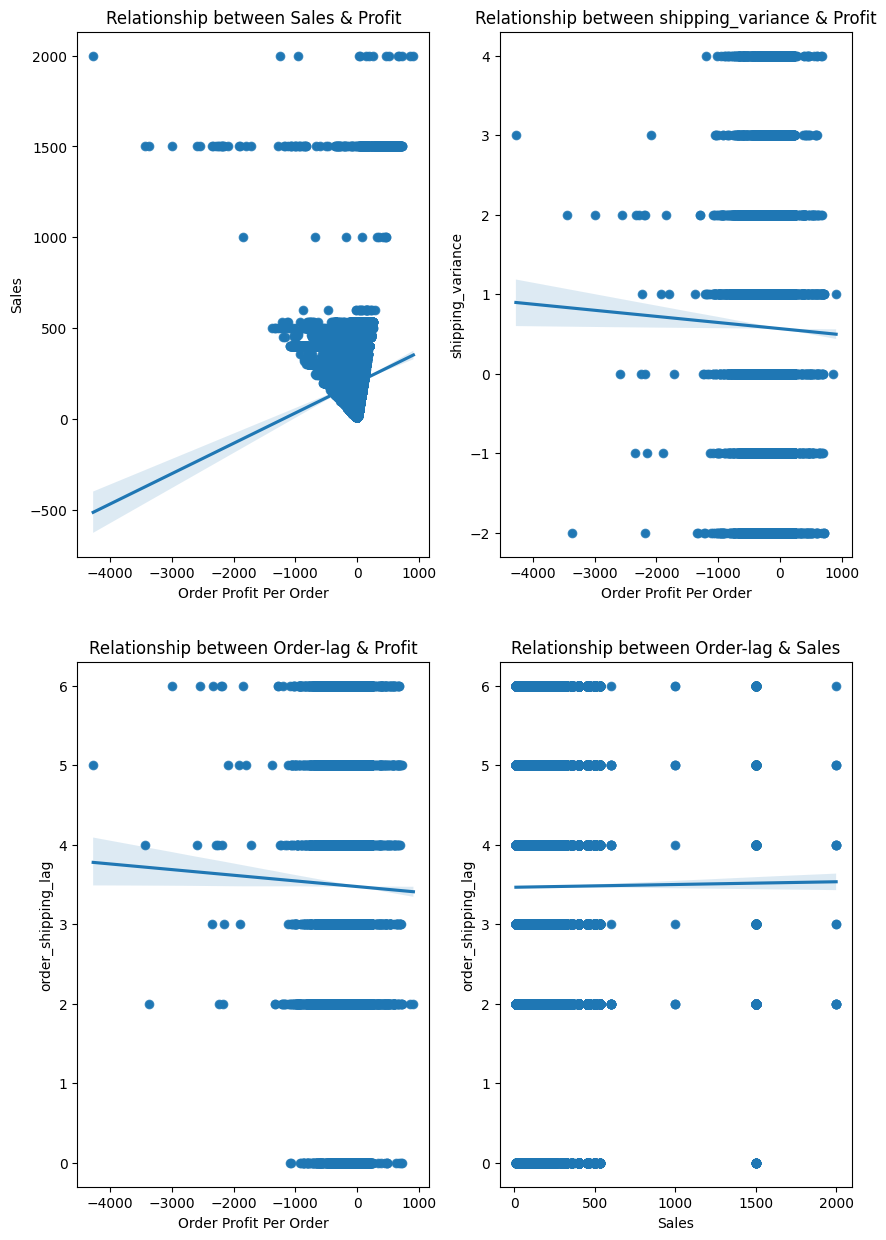

In [14]:
# scatter plots and regression line to fine relationship between variables

fig,axes=plt.subplots(nrows=2,ncols=2, figsize=(10,15))
axes[0,0].set_title("Relationship between Sales & Profit")
sns.scatterplot(data=df, ax=axes[0,0], x="Order Profit Per Order", y="Sales")
sns.regplot(data=df, ax=axes[0,0], x="Order Profit Per Order", y="Sales")

axes[0,1].set_title("Relationship between shipping_variance & Profit")
sns.scatterplot(data=df, ax=axes[0,1], x="Order Profit Per Order", y="shipping_variance")
sns.regplot(data=df, ax=axes[0,1], x="Order Profit Per Order", y="shipping_variance")

axes[1,0].set_title("Relationship between Order-lag & Profit")
sns.scatterplot(data=df, ax=axes[1,0], x="Order Profit Per Order", y="order_shipping_lag")
sns.regplot(data=df, ax=axes[1,0], x="Order Profit Per Order", y="order_shipping_lag")

axes[1,1].set_title("Relationship between Order-lag & Sales")
sns.scatterplot(data=df, ax=axes[1,1], x="Sales", y="order_shipping_lag")
sns.regplot(data=df, ax=axes[1,1], x="Sales", y="order_shipping_lag")

plt.tight_layout